# LPCMCI + FAISS-CMI — Model-Free, Latent-Confounder-Robust Causal Discovery

`lpcmci_parcorr.ipynb` and `lpcmci_gpdc.ipynb` pair LPCMCI with a linear and a nonlinear-additive CI
test respectively. This notebook pairs LPCMCI with **FAISSCMI**, the same Kraskov kNN conditional
mutual information estimator `pcmci_cmi.ipynb` implements inline — model-free, detects any
statistical dependency (nonlinear, non-additive, non-monotone) — combined with LPCMCI's ability to
tell a genuine cause (`-->`) apart from a link that is merely confounded by an unobserved common
driver (`<->`); see `lpcmci_parcorr.ipynb`'s intro for the full DPAG edge-type legend.

CMI's shuffle test makes every conditional-independence call `1 + sig_samples` CMI evaluations, and
LPCMCI issues far more CI calls than plain PCMCI. The Runtime Tuning section documents the measured
cost and the reduced `sig_samples` this notebook uses relative to `pcmci_cmi.ipynb`'s production
setting.

The `FAISSCMI` class is implemented inline (not imported from external source), exactly as in
`pcmci_cmi.ipynb`.

Preprocessing identical to `eda_preprocessing.ipynb`: interpolate -> ffill -> Gaussian detrend (15-yr)
-> anomalize -> `pp.trafo2normal`.

## Imports & Configuration

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')

import sys
from pathlib import Path
from typing import Any
import time

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import digamma

import faiss
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.lpcmci import LPCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.independence_tests_base import CondIndTest

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ─────────────────────────────────────────────────────────────
CROPS     = ['corn', 'soybean', 'wheat']
FREQUENCY = 'monthly'

CYCLE_LEN    = 12
SMOOTH_WIDTH = 15 * CYCLE_LEN

METHOD_LABEL     = 'FAISS-CMI'
TAU_MAX          = 1      # LPCMCI's own tau_max — shorter than pcmci_cmi.ipynb's 3 (Runtime Tuning)
BASELINE_TAU_MAX = 3      # tau_max used for the PCMCI+FAISS-CMI comparison, matching pcmci_cmi.ipynb

# LPCMCI-specific parameters
PC_ALPHA                 = 0.01
N_PRELIMINARY_ITERATIONS = 0
MAX_P_GLOBAL             = 1
MAX_P_NON_ANCESTRAL      = 0
MAX_COND_PX              = 0
MAX_Q_GLOBAL             = 1

# FAISSCMI itself
CMI_K           = 0.1   # fractional -> resolved to int(k*T) per call
CMI_SIG_SAMPLES = 50    # reduced from pcmci_cmi.ipynb's 200 — see Runtime Tuning
RANDOM_SEED     = 42

ALPHA_LEVEL = 0.05
FDR_METHOD  = 'fdr_bh'

print(f'Crops     : {CROPS}')
print(f'Frequency : {FREQUENCY}')
print(f'tau_max   : {TAU_MAX}  (baseline comparison uses tau_max={BASELINE_TAU_MAX})')
print(f'pc_alpha  : {PC_ALPHA}')
print(f'cmi_k / cmi_sig_samples : {CMI_K} / {CMI_SIG_SAMPLES}')
print(f'max_p_global / max_p_non_ancestral / max_q_global : '
      f'{MAX_P_GLOBAL} / {MAX_P_NON_ANCESTRAL} / {MAX_Q_GLOBAL}')

Crops     : ['corn', 'soybean', 'wheat']
Frequency : monthly
tau_max   : 1  (baseline comparison uses tau_max=3)
pc_alpha  : 0.01
cmi_k / cmi_sig_samples : 0.1 / 50
max_p_global / max_p_non_ancestral / max_q_global : 1 / 0 / 1


## Backend Detection

FAISS supports **CUDA GPU** and **CPU** only — it does **not** use MPS (Apple Silicon). On macOS
M-series, FAISSCMI falls back to CPU automatically.

In [2]:
_faiss_gpu_count = 0
FAISS_USE_GPU    = False
_gpu_init_error  = None

try:
    _faiss_gpu_count = faiss.get_num_gpus() if hasattr(faiss, 'get_num_gpus') else 0
except Exception as _e:
    _faiss_gpu_count = 0
    _gpu_init_error  = f'get_num_gpus failed: {_e}'

if _faiss_gpu_count > 0 and _gpu_init_error is None:
    try:
        _res  = faiss.StandardGpuResources()
        _flat = faiss.IndexFlatL2(4)
        _gidx = faiss.index_cpu_to_gpu(_res, 0, _flat)
        _data = np.random.rand(16, 4).astype(np.float32)
        _gidx.add(_data)
        _gidx.search(_data[:2], 3)
        FAISS_USE_GPU = True
        del _res, _flat, _gidx, _data
    except Exception as _e:
        FAISS_USE_GPU   = False
        _gpu_init_error = str(_e)

print(f'faiss version    : {faiss.__version__}')
print(f'FAISS GPU count  : {_faiss_gpu_count}')
print(f'FAISS GPU active : {FAISS_USE_GPU}')
if _gpu_init_error:
    print(f'GPU init error   : {_gpu_init_error}')
print('Backend:', 'CUDA GPU' if FAISS_USE_GPU else 'CPU')

faiss version    : 1.14.1
FAISS GPU count  : 0
FAISS GPU active : False
Backend: CPU


## FAISSCMI — FAISS-backed CMI Estimator (implemented inline, as in `pcmci_cmi.ipynb`)

In [3]:
class FAISSCMI(CondIndTest):
    """Kraskov-Stogbauer-Grassberger (KSG) k-NN conditional mutual information,
    Frenzel-Pompe (2007) conditional extension. Identical to the class in `pcmci_cmi.ipynb`."""

    X_ID = 0
    Y_ID = 1
    Z_ID = 2
    FAISS_T_THRESHOLD = 1500

    @property
    def measure(self) -> Any:
        return self._measure

    def __init__(
        self,
        k: float = 0.1,
        *,
        use_gpu: bool = True,
        gpu_device: int = 0,
        transform: str = "ranks",
        jitter: float = 1e-6,
        significance: str = "shuffle_test",
        **kwargs: Any,
    ) -> None:
        if isinstance(k, float) and not (0.0 < k < 1.0):
            raise ValueError("Fractional k must be in (0, 1); got %r" % (k,))
        if isinstance(k, int) and k < 1:
            raise ValueError("Absolute k must be >= 1; got %r" % (k,))
        if transform not in ("ranks", "standardize"):
            raise ValueError(f"transform must be 'ranks' or 'standardize', got {transform!r}")
        if significance == "analytic":
            raise ValueError("FAISSCMI does not support analytic significance; use 'shuffle_test'.")

        self.knn_param         = k
        self.k                 = None
        self.transform         = transform
        self.use_gpu           = use_gpu
        self.gpu_device        = gpu_device
        self.jitter            = jitter
        self._measure          = "faiss_cmi"
        self.two_sided         = False
        self.residual_based    = False
        self.recycle_residuals = False
        self.res = self._build_gpu_resources() if use_gpu else None
        CondIndTest.__init__(self, significance=significance, **kwargs)

    def __getstate__(self) -> dict:
        state = self.__dict__.copy()
        state["res"] = None
        return state

    def __setstate__(self, state: dict) -> None:
        self.__dict__.update(state)
        self.res = self._build_gpu_resources() if self.use_gpu else None

    def _build_gpu_resources(self) -> Any | None:
        std_gpu = getattr(faiss, 'StandardGpuResources', None)
        if std_gpu is None:
            return None
        try:
            res = std_gpu()
            to_gpu = getattr(faiss, 'index_cpu_to_gpu', None)
            if to_gpu is not None:
                _test = to_gpu(res, self.gpu_device, faiss.IndexFlatL2(2))
                del _test
            return res
        except Exception:
            self.use_gpu = False
            return None

    def _build_index(self, dim: int) -> Any:
        cpu_index = faiss.IndexFlatL2(dim)
        to_gpu    = getattr(faiss, "index_cpu_to_gpu", None)
        if self.res is None or to_gpu is None:
            return cpu_index
        try:
            return to_gpu(self.res, self.gpu_device, cpu_index)
        except Exception:
            return cpu_index

    def _resolve_k(self, T: int) -> int:
        if isinstance(self.knn_param, float):
            return max(1, int(round(self.knn_param * T)))
        return int(self.knn_param)

    def _prepare_array(self, array: np.ndarray) -> np.ndarray:
        from scipy.stats import rankdata

        prepared = np.asarray(array, dtype=np.float64).copy()

        if self.transform == "ranks":
            T = prepared.shape[1]
            for i in range(prepared.shape[0]):
                prepared[i] = (rankdata(prepared[i], method="average") - 1.0) / max(T - 1, 1)
        else:
            prepared -= prepared.mean(axis=1, keepdims=True)
            std = prepared.std(axis=1, keepdims=True)
            std[std == 0.0] = 1.0
            prepared /= std

        if self.jitter > 0.0:
            scale = prepared.std(axis=1, keepdims=True)
            scale[scale == 0.0] = 1.0
            prepared += self.jitter * scale * self.random_state.standard_normal(prepared.shape)
        return prepared

    @staticmethod
    def _chebyshev_dist_matrix(data: np.ndarray) -> np.ndarray:
        return np.abs(data[:, None, :] - data[None, :, :]).max(axis=2)

    def _knn_radius(self, data: np.ndarray) -> np.ndarray:
        T = data.shape[0]
        if T > self.FAISS_T_THRESHOLD and self.res is not None:
            return self._knn_radius_faiss_refined(data)
        dist_mat = self._chebyshev_dist_matrix(data)
        return np.partition(dist_mat, self.k, axis=1)[:, self.k]

    def _knn_radius_faiss_refined(self, data: np.ndarray) -> np.ndarray:
        T, D = data.shape
        samples = np.ascontiguousarray(data, dtype=np.float32)
        k_cand = min(T, max(50, 8 * self.k + 1))
        index  = self._build_index(D)
        index.add(samples)
        _, nbr = index.search(samples, k_cand)
        eps = np.empty(T, dtype=np.float64)
        for i in range(T):
            cands = data[nbr[i]]
            linf  = np.abs(cands - data[i]).max(axis=1)
            eps[i] = np.partition(linf, self.k)[self.k]
        return eps

    def _count_neighbors(self, space: np.ndarray, eps: np.ndarray) -> np.ndarray:
        T, d = space.shape
        if d == 0:
            return np.full(T, T - 1, dtype=np.float64)
        dist_mat = self._chebyshev_dist_matrix(space)
        return (dist_mat < eps[:, None]).sum(axis=1).astype(np.float64) - 1.0

    def get_dependence_measure(
        self,
        array: np.ndarray,
        xyz: np.ndarray,
        data_type: np.ndarray | None = None,
    ) -> float:
        del data_type
        self.k = self._resolve_k(array.shape[1])

        prepared = self._prepare_array(array)
        x = prepared[xyz == self.X_ID].T
        y = prepared[xyz == self.Y_ID].T
        z = prepared[xyz == self.Z_ID].T

        xyz_joint = np.column_stack([x, y, z])
        xz_space  = np.column_stack([x, z])
        yz_space  = np.column_stack([y, z])

        eps  = self._knn_radius(xyz_joint)
        n_xz = self._count_neighbors(xz_space, eps)
        n_yz = self._count_neighbors(yz_space, eps)
        n_z  = self._count_neighbors(z, eps)

        return float(
            digamma(self.k)
            + np.mean(digamma(n_z  + 1.0))
            - np.mean(digamma(n_xz + 1.0) + digamma(n_yz + 1.0))
        )

    def get_shuffle_significance(
        self,
        array: np.ndarray,
        xyz: np.ndarray,
        value: float,
        data_type: np.ndarray | None = None,
        return_null_dist: bool = False,
    ) -> Any:
        del data_type
        try:
            null_dist = self._get_shuffle_dist(
                array, xyz, self.get_dependence_measure,
                sig_samples=self.sig_samples,
                sig_blocklength=self.sig_blocklength,
                verbosity=self.verbosity,
            )
        except (TypeError, ValueError):
            null_dist = self._get_shuffle_dist(
                array, xyz, self.get_dependence_measure,
                sig_samples=self.sig_samples,
                sig_blocklength=1,
                verbosity=self.verbosity,
            )
        pval = float(np.sum(null_dist >= value) + 1) / (self.sig_samples + 1)
        if return_null_dist:
            return pval, null_dist
        return pval


print('FAISSCMI class defined.')

FAISSCMI class defined.


## Feature Group Definitions

In [4]:
FEATURE_GROUPS = {
    'rv'     : ['weekly_rv'],
    'climate': ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi',
                'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct',
                'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index'],
    'macro'  : ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'],
    'news'   : ['frbsf_sentiment', 'epu_index', 'Text_Climate_Anomaly'],
}

GROUP_COLORS = {
    'rv': '#e41a1c', 'climate': '#377eb8', 'macro': '#4daf4a', 'news': '#984ea3',
}

FEATURE_SETS = {
    'climate'              : ['climate'],
    'climate_rv'           : ['climate', 'rv'],
    'macro_climate_rv'     : ['macro', 'climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

def build_cols(groups: list[str]) -> list[str]:
    cols: list[str] = []
    for g in groups:
        cols.extend(FEATURE_GROUPS[g])
    return cols

def group_of(col: str) -> str:
    for g, cols in FEATURE_GROUPS.items():
        if col in cols:
            return g
    return 'other'

for name, groups in FEATURE_SETS.items():
    print(f'{name:30s}: {len(build_cols(groups)):2d} vars')

climate                       : 14 vars
climate_rv                    : 15 vars
macro_climate_rv              : 19 vars
macro_news_climate_rv         : 22 vars


## Preprocessing Pipeline

Identical to `eda_preprocessing.ipynb` and every other `pcmci_*.ipynb` / `lpcmci_*.ipynb` notebook in
this project, so results stay comparable across notebooks.

| Step | Method | Why |
|------|--------|-----|
| Impute | Interpolate `pdsi`/`Broad_Dollar_index`, ffill `DJIA_Index` | Fill isolated gaps before detrending |
| Detrend | `pp.smooth(residuals=True, kernel='gaussian', smooth_width=15yr)` | Removes secular drift that would inflate long-range spurious links |
| Anomalize | Subtract phase mean, divide by phase std | Removes annual seasonality |
| Gaussianise | `pp.trafo2normal` | Marginal Gaussianity validates ParCorr's analytic t-test used inside LPCMCI (and inside `run_bivci`'s `tau_max` scan) |

In [5]:
def load_and_preprocess(crop: str, frequency: str) -> tuple[np.ndarray, list[str], pd.Series]:
    """Load CSV, impute, detrend, anomalize, Gaussianise. Returns (arr_normal, col_names, dates)."""
    path = ROOT / 'data' / frequency / f'{crop}.csv'
    raw  = pd.read_csv(path, parse_dates=['date'])
    df   = raw.sort_values('date').reset_index(drop=True)

    for col in ['pdsi', 'Broad_Dollar_index']:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
    for col in ['DJIA_Index']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()
    df = df.dropna().reset_index(drop=True)

    col_names = [c for c in df.columns if c != 'date']
    arr = df[col_names].values.astype(float)

    cycle_len    = 52 if frequency == 'weekly' else 12
    smooth_width = 15 * cycle_len
    arr_detrended = pp.smooth(arr, smooth_width=smooth_width, kernel='gaussian', residuals=True)

    arr_anom = arr_detrended.copy().astype(float)
    for phase in range(cycle_len):
        idx = slice(phase, None, cycle_len)
        arr_anom[idx] -= arr_detrended[idx].mean(axis=0)
        std = arr_detrended[idx].std(axis=0)
        std[std == 0] = 1.0
        arr_anom[idx] /= std

    arr_normal = pp.trafo2normal(arr_anom)
    return arr_normal, col_names, df['date']


print('Preprocessing function defined.')

Preprocessing function defined.


## Preprocessed Data Overview

All plots below use data after the full pipeline (impute -> detrend -> anomalize -> Gaussianise).

- **Time series** — all 22 variables for corn (representative crop) after preprocessing
- **Cross-correlations** — CCF of each variable X at lags 0..3 against `weekly_rv`, shown for all three crops simultaneously

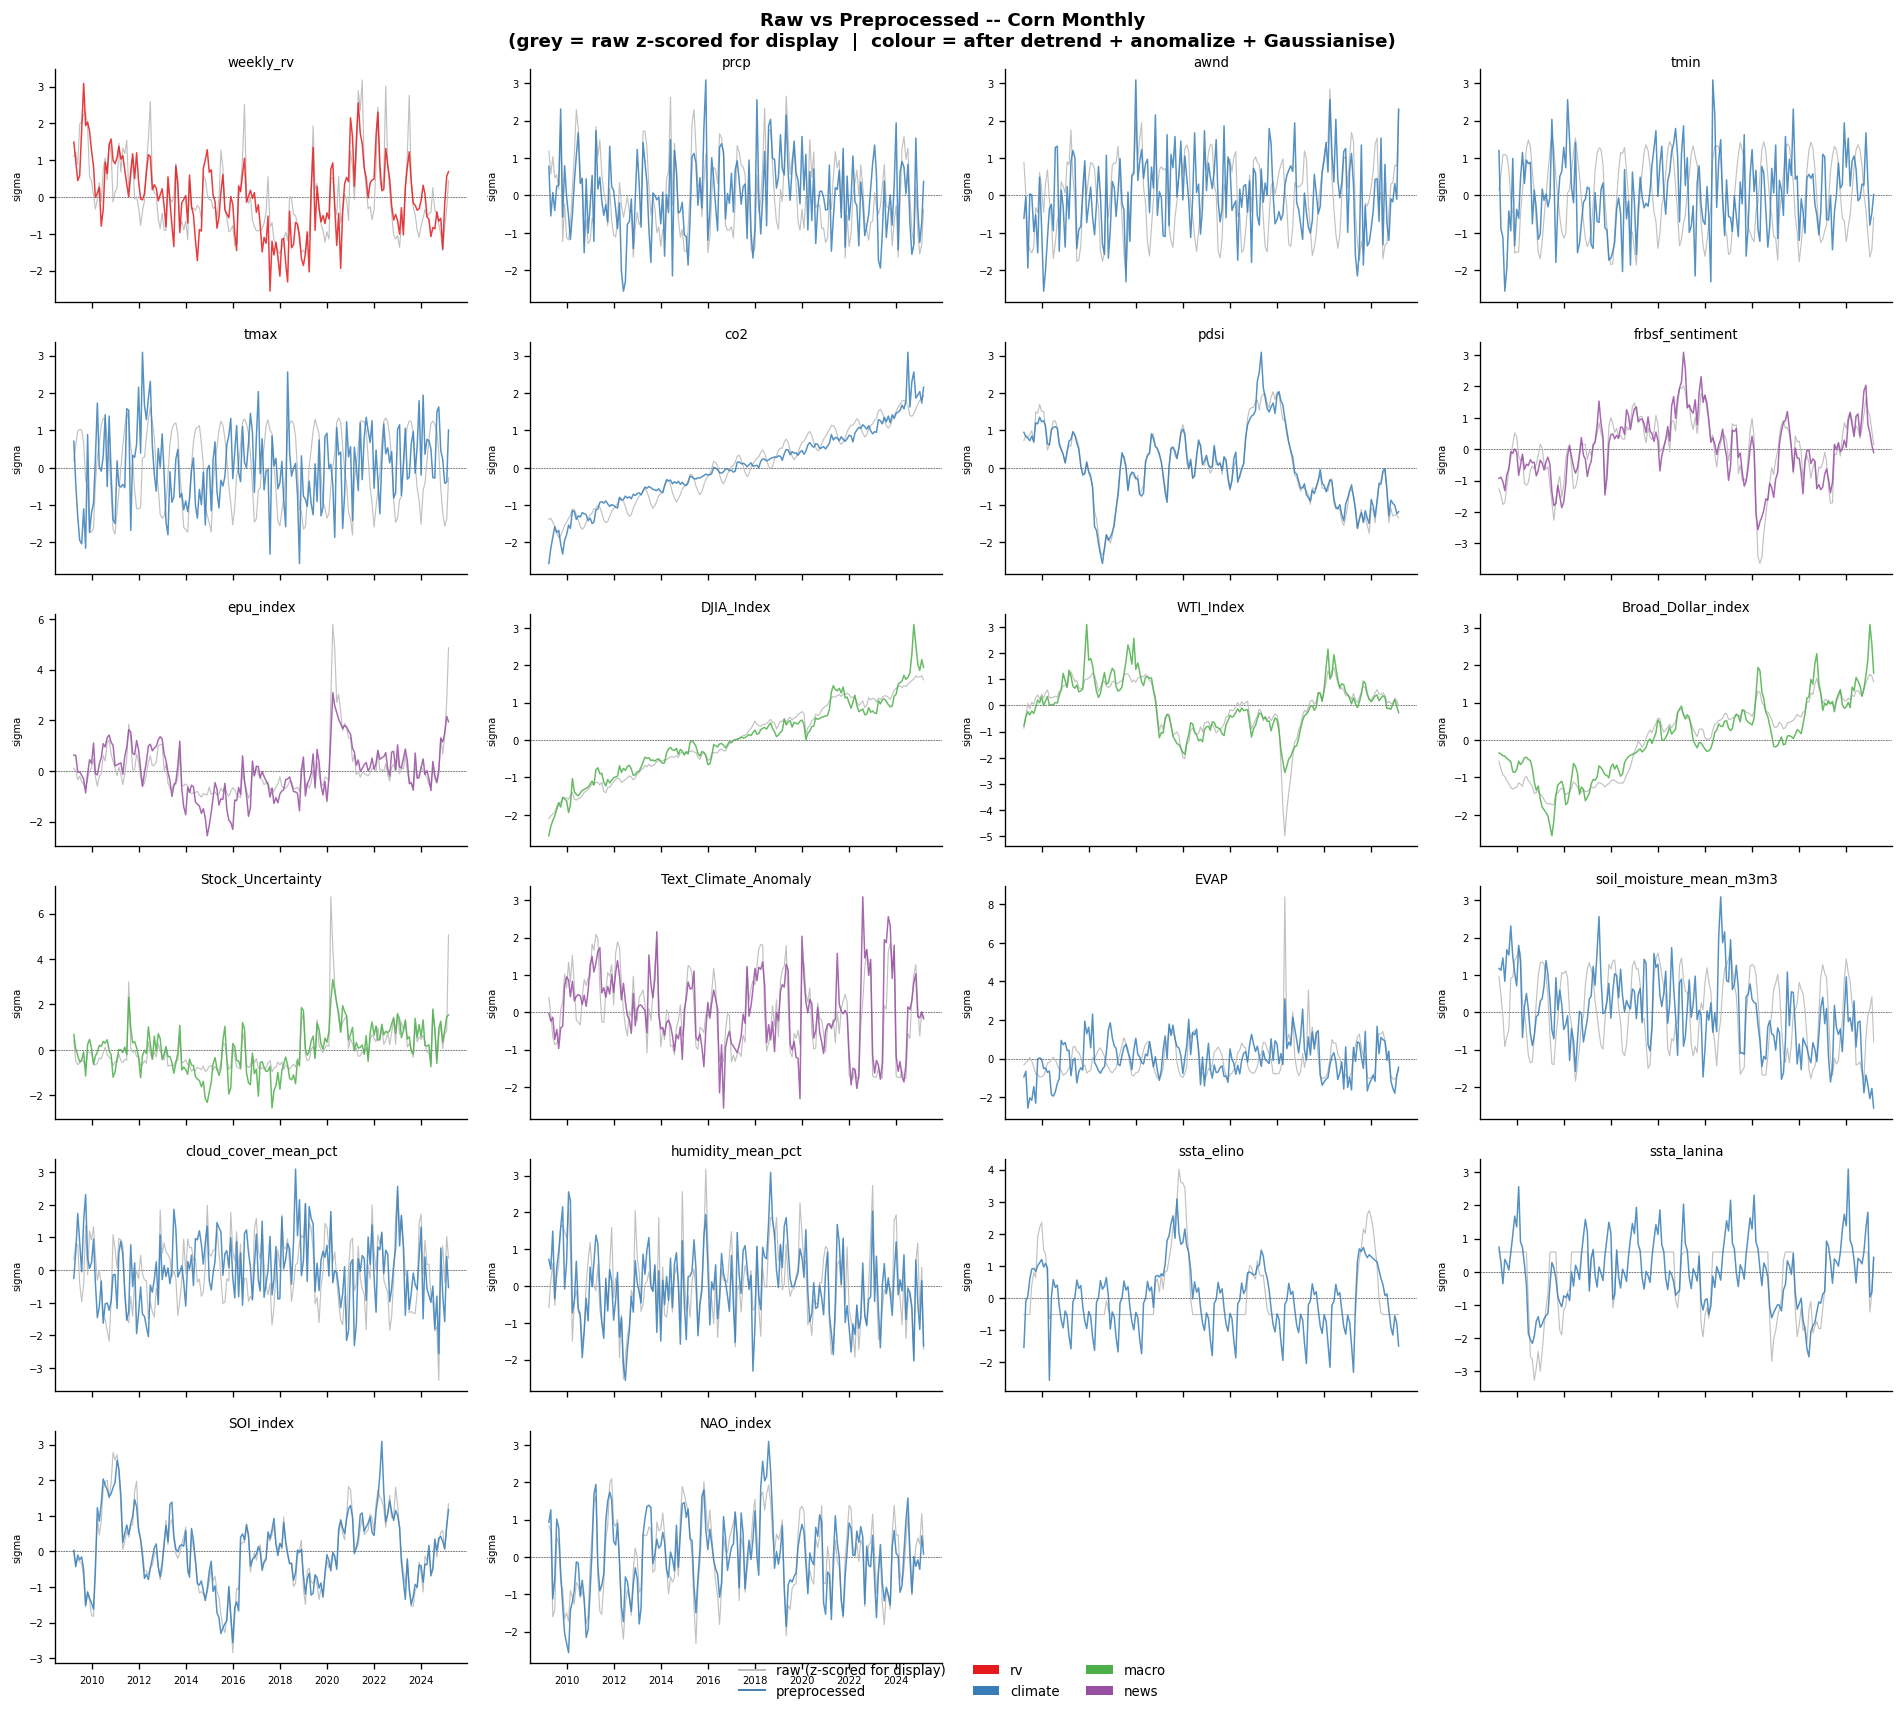

In [6]:
from matplotlib.patches import Patch as _Patch
from matplotlib.lines import Line2D as _Line2D

_raw_df    = pd.read_csv(ROOT / 'data' / FREQUENCY / 'corn.csv', parse_dates=['date'])
_raw_cols  = [c for c in _raw_df.columns if c != 'date']
_raw_arr   = _raw_df[_raw_cols].values.astype(float)
_raw_dates = _raw_df['date']

_arr0, _cols0, _dates0 = load_and_preprocess('corn', FREQUENCY)
_N   = len(_cols0)
_ncg = 4
_nrg = (_N + _ncg - 1) // _ncg

fig, axes = plt.subplots(_nrg, _ncg, figsize=(_ncg * 4, _nrg * 2.4), sharex=True)
axes = axes.flatten()
for i, col in enumerate(_cols0):
    ax = axes[i]
    color = GROUP_COLORS.get(group_of(col), '#888')
    if col in _raw_cols:
        _r     = _raw_arr[:, _raw_cols.index(col)].astype(float)
        _r_std = _r.std()
        _r_z   = (_r - _r.mean()) / (_r_std if _r_std > 0 else 1.0)
        ax.plot(_raw_dates, _r_z, lw=0.7, color='#bbbbbb', alpha=0.9, zorder=1)
    ax.plot(_dates0, _arr0[:, i], lw=0.9, color=color, alpha=0.85, zorder=2)
    ax.axhline(0, color='k', lw=0.3, ls='--', zorder=0)
    ax.set_title(col, fontsize=8, pad=2)
    ax.tick_params(labelsize=6)
    ax.set_ylabel('sigma', fontsize=6)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
for ax in axes[_N:]:
    ax.set_visible(False)
_leg = [_Line2D([0],[0], color='#bbbbbb', lw=1.2, label='raw (z-scored for display)'),
        _Line2D([0],[0], color='steelblue', lw=1.2, label='preprocessed')]
_leg += [_Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=_leg, loc='lower center', ncol=3, fontsize=8, frameon=False)
fig.suptitle(
    f'Raw vs Preprocessed -- Corn {FREQUENCY.capitalize()}\n'
    '(grey = raw z-scored for display  |  colour = after detrend + anomalize + Gaussianise)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

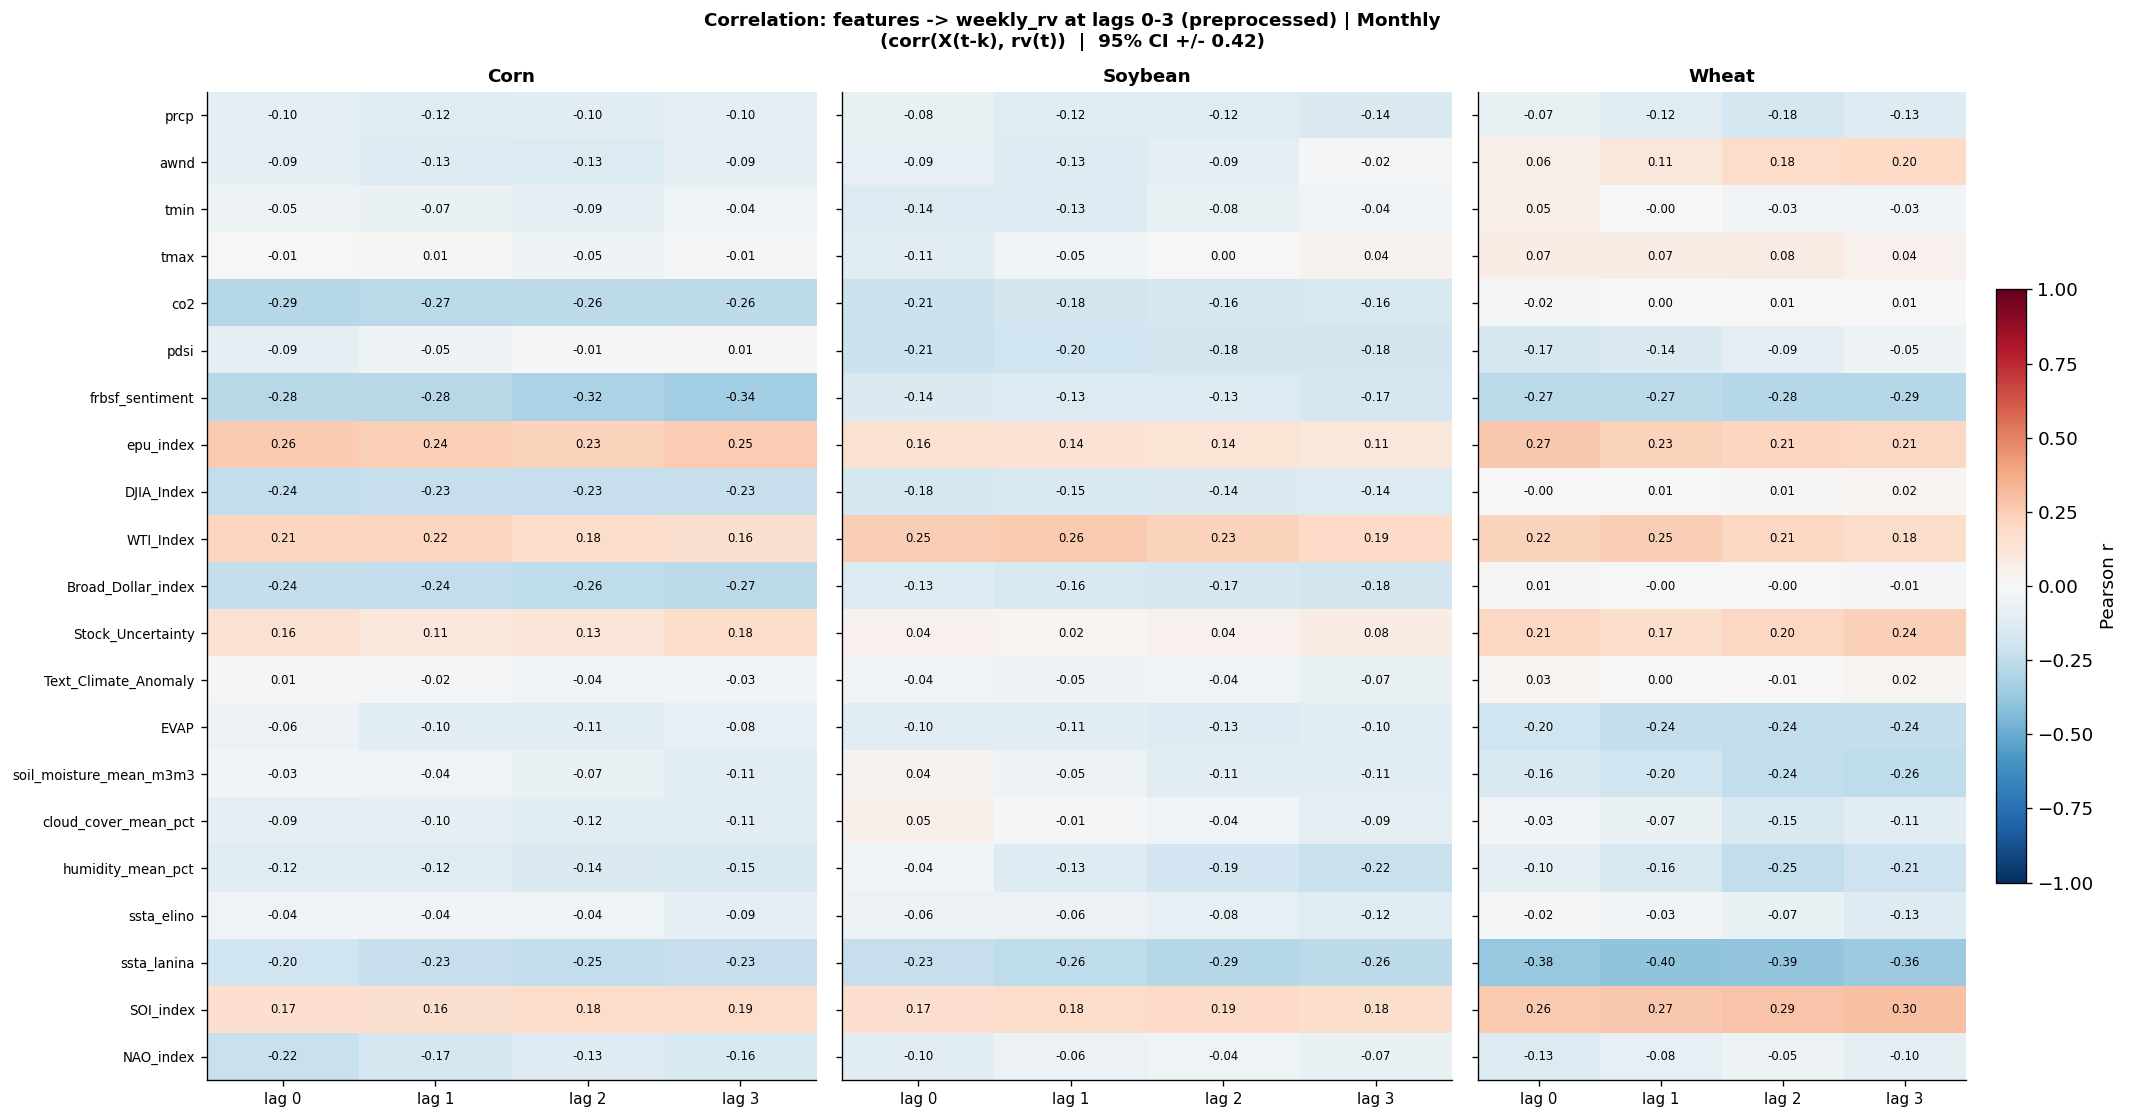

In [7]:
_preproc = {}
for _crop in CROPS:
    _a, _c, _d = load_and_preprocess(_crop, FREQUENCY)
    _preproc[_crop] = (_a, _c, _d)

_LAGS  = [0, 1, 2, 3]
_other = [c for c in _cols0 if c != 'weekly_rv']
_n_oth = len(_other)
_ci    = 1.96 / np.sqrt(_N)

fig, axes = plt.subplots(1, 3, figsize=(18, max(7, _n_oth * 0.38 + 1.5)), sharey=True)

for ax, crop in zip(axes, CROPS):
    arr, cols, _ = _preproc[crop]
    if 'weekly_rv' not in cols:
        continue
    rv = arr[:, cols.index('weekly_rv')]

    corr_mat = np.full((_n_oth, len(_LAGS)), np.nan)
    for li, lag in enumerate(_LAGS):
        for fi, feat in enumerate(_other):
            if feat not in cols:
                continue
            x = arr[:, cols.index(feat)]
            corr_mat[fi, li] = np.corrcoef(x[: len(x) - lag] if lag else x,
                                            rv[lag:] if lag else rv)[0, 1]

    im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(_LAGS)))
    ax.set_xticklabels([f'lag {l}' for l in _LAGS], fontsize=9)
    ax.set_yticks(range(_n_oth))
    ax.set_yticklabels(_other, fontsize=8)

    for fi in range(_n_oth):
        for li in range(len(_LAGS)):
            val = corr_mat[fi, li]
            if not np.isnan(val):
                ax.text(li, fi, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if abs(val) > 0.5 else 'black')

    ax.set_title(crop.capitalize(), fontsize=11, fontweight='bold')

plt.colorbar(im, ax=axes[-1], shrink=0.6, label='Pearson r')
fig.suptitle(
    f'Correlation: features -> weekly_rv at lags 0-3 (preprocessed) | {FREQUENCY.capitalize()}\n'
    f'(corr(X(t-k), rv(t))  |  95% CI +/- {_ci:.2f})',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## Choosing `tau_max` — Bivariate Lagged CI (tutorial S3.3)

The LPCMCI tutorial recommends running `PCMCI.run_bivci` first — a bivariate lag-function scan,
similar to Granger causality but lag-specific — to check `tau_max` is large enough to capture the
decay of dependence. `run_bivci` always uses ParCorr internally (it is a cheap linear pre-check,
independent of which CI test LPCMCI itself will use below).

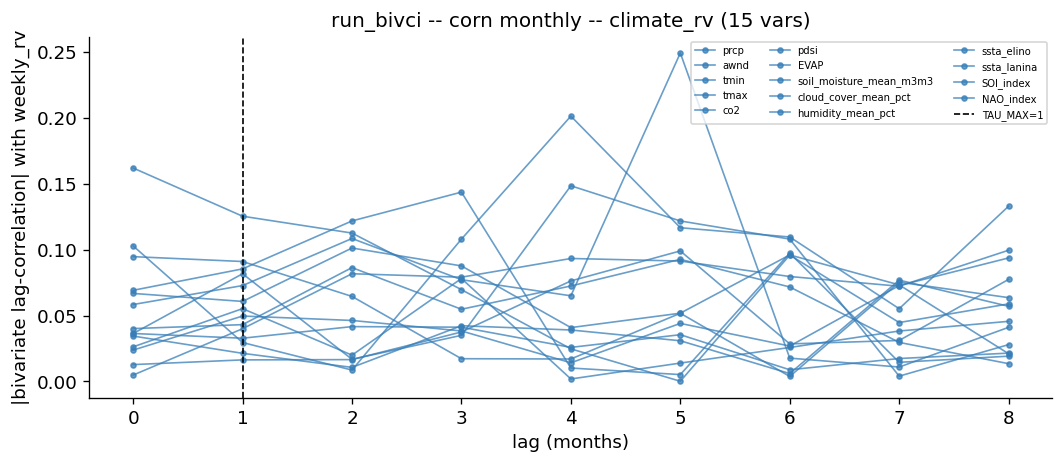

In [8]:
_arr_bv, _cols_bv, _dates_bv = load_and_preprocess('corn', FREQUENCY)
_bv_cols = [c for c in build_cols(FEATURE_SETS['climate_rv']) if c in _cols_bv]
_bv_idx  = [_cols_bv.index(c) for c in _bv_cols]
_arr_bv_sub = _arr_bv[:, _bv_idx]

_dataframe_bv = pp.DataFrame(_arr_bv_sub, var_names=_bv_cols, datatime={0: np.arange(len(_arr_bv_sub))})
_parcorr_bv   = ParCorr(significance='analytic')
_pcmci_bv     = PCMCI(dataframe=_dataframe_bv, cond_ind_test=_parcorr_bv, verbosity=0)

_biv_val = _pcmci_bv.run_bivci(tau_max=8, val_only=True)['val_matrix']
_rv_idx  = _bv_cols.index('weekly_rv')

fig, ax = plt.subplots(figsize=(9, 4))
_lags = np.arange(9)
for i, c in enumerate(_bv_cols):
    if c == 'weekly_rv':
        continue
    ax.plot(_lags, np.abs(_biv_val[i, _rv_idx, :]), marker='o', ms=3, lw=1,
             color=GROUP_COLORS.get(group_of(c), '#888'), alpha=0.75, label=c)
ax.axvline(TAU_MAX, color='k', ls='--', lw=1, label=f'TAU_MAX={TAU_MAX}')
ax.set_xlabel('lag (months)')
ax.set_ylabel('|bivariate lag-correlation| with weekly_rv')
ax.set_title(f'run_bivci -- corn {FREQUENCY} -- climate_rv ({len(_bv_cols)} vars)')
ax.legend(fontsize=6, ncol=3, loc='upper right')
plt.tight_layout()
plt.show()

## LPCMCI + FAISS-CMI Helper Functions

In [9]:
EDGE_INFO = {
    '-->': ('directed',            'candidate cause (i -> j); may still be confounded unless "visible"'),
    '<->': ('confounded',          'no causal link either way -- both driven by an unobserved common cause'),
    'o->': ('uncertain-directed',  'j does not cause i; whether i -> j or i <-> j is undetermined'),
    'x->': ('conflicting-directed','orientation rules disagree on whether i -> j or i <-> j'),
    'o-o': ('uncertain',           'fully undetermined: could be i -> j, j -> i, or i <-> j'),
    'x-x': ('conflicting',         'orientation rules disagree even on the direction of causal flow'),
}

CATEGORY_STYLE = {
    'directed':             dict(color='#2b8a3e', dashes=False, arrow_both=False, label='directed (candidate cause)'),
    'confounded':           dict(color='#c92a2a', dashes=True,  arrow_both=True,  label='confounded (latent common cause)'),
    'uncertain-directed':   dict(color='#e8590c', dashes=True,  arrow_both=False, label='uncertain, not reverse-causal'),
    'uncertain':            dict(color='#868e96', dashes=True,  arrow_both=False, label='fully uncertain'),
    'conflicting-directed': dict(color='#9c36b5', dashes=True,  arrow_both=False, label='conflicting orientation'),
    'conflicting':          dict(color='#9c36b5', dashes=True,  arrow_both=True,  label='conflicting orientation'),
}


def _fdr_bh(p_matrix: np.ndarray, exclude_contemporaneous: bool = False) -> np.ndarray:
    """Benjamini-Hochberg FDR correction, reimplemented directly on p_matrix.

    tigramite 5.2.10.1's LPCMCI.get_corrected_pvalues (inherited from PCMCIbase) raises
    AttributeError on self._check_tau_limits, which is only defined on the PCMCI subclass --
    a version bug. This reproduces the same BH procedure without going through that method.
    """
    N = p_matrix.shape[0]
    mask = np.ones(p_matrix.shape, dtype=bool)
    mask[range(N), range(N), 0] = False
    if exclude_contemporaneous:
        mask[:, :, 0] = False

    q_matrix = p_matrix.copy()
    pvs = p_matrix[mask]
    if len(pvs) > 0:
        sortind = np.argsort(pvs)
        pvals_sorted = pvs[sortind]
        ecdffactor = np.arange(1, len(pvs) + 1) / float(len(pvs))
        pvals_corrected = np.minimum.accumulate((pvals_sorted / ecdffactor)[::-1])[::-1]
        pvals_corrected[pvals_corrected > 1] = 1
        out = np.empty_like(pvals_corrected)
        out[sortind] = pvals_corrected
        q_matrix[mask] = out
    return q_matrix

In [10]:
def run_lpcmci(
    col_names: list[str],
    arr_preprocessed: np.ndarray,
    all_cols: list[str],
    tau_max: int,
    pc_alpha: float = PC_ALPHA,
    n_preliminary_iterations: int = N_PRELIMINARY_ITERATIONS,
    max_p_global: int = MAX_P_GLOBAL,
    max_p_non_ancestral: int = MAX_P_NON_ANCESTRAL,
    max_cond_px: int = MAX_COND_PX,
    max_q_global: int = MAX_Q_GLOBAL,
    verbosity: int = 0,
) -> dict:
    indices     = [all_cols.index(c) for c in col_names]
    data_subset = arr_preprocessed[:, indices]

    dataframe = pp.DataFrame(
        data_subset,
        var_names=col_names,
        datatime={0: np.arange(len(data_subset))},
    )
    cmi = FAISSCMI(
        k=CMI_K, use_gpu=FAISS_USE_GPU, gpu_device=0,
        transform='ranks', jitter=1e-6,
        significance='shuffle_test', sig_samples=CMI_SIG_SAMPLES, seed=RANDOM_SEED,
    )
    lpcmci = LPCMCI(dataframe=dataframe, cond_ind_test=cmi, verbosity=verbosity)

    results = lpcmci.run_lpcmci(
        tau_min=0, tau_max=tau_max,
        pc_alpha=pc_alpha,
        n_preliminary_iterations=n_preliminary_iterations,
        max_p_global=max_p_global,
        max_p_non_ancestral=max_p_non_ancestral,
        max_cond_px=max_cond_px,
        max_q_global=max_q_global,
    )
    q_matrix = _fdr_bh(results['p_matrix'], exclude_contemporaneous=False)
    results.update({
        'q_matrix': q_matrix, 'lpcmci': lpcmci,
        'col_names': col_names, 'data_subset': data_subset,
    })
    return results

In [11]:
def _lagged_edge_category(sym: str) -> str | None:
    """Lag > 0: only 'forward' symbols occur (arrowhead points from i to j)."""
    return EDGE_INFO[sym][0] if sym in EDGE_INFO else None


def _contemp_edge(graph: np.ndarray, i: int, j: int) -> tuple[str, int, int] | None:
    """Lag == 0: combine graph[i,j,0] and graph[j,i,0] into (category, source, target)."""
    sym_ij, sym_ji = graph[i, j, 0], graph[j, i, 0]
    if sym_ij == '' or sym_ji == '':
        return None
    if sym_ij == '-->' and sym_ji == '<--':
        return ('directed', i, j)
    if sym_ij == '<--' and sym_ji == '-->':
        return ('directed', j, i)
    if sym_ij == '<->' and sym_ji == '<->':
        return ('confounded', i, j)
    if sym_ij == 'o->' and sym_ji == '<-o':
        return ('uncertain-directed', i, j)
    if sym_ij == '<-o' and sym_ji == 'o->':
        return ('uncertain-directed', j, i)
    if sym_ij == 'o-o' and sym_ji == 'o-o':
        return ('uncertain', i, j)
    if 'x' in sym_ij or 'x' in sym_ji:
        return ('conflicting', i, j)
    return None


def _edges_dataframe(results: dict) -> pd.DataFrame:
    """Every edge in the learned DPAG (lagged + contemporaneous), classified by causal status."""
    col_names  = results['col_names']
    graph      = results['graph']
    val_matrix = results['val_matrix']
    q_matrix   = results['q_matrix']
    N          = len(col_names)
    tau_max    = graph.shape[2] - 1

    rows = []
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            for tau in range(1, tau_max + 1):
                cat = _lagged_edge_category(graph[i, j, tau])
                if cat is None:
                    continue
                rows.append({
                    'cause': col_names[i], 'effect': col_names[j], 'lag': tau,
                    'category': cat, 'mci_val': val_matrix[i, j, tau],
                    'q_val': q_matrix[i, j, tau],
                })
        for j in range(i + 1, N):
            edge = _contemp_edge(graph, i, j)
            if edge is None:
                continue
            cat, src, tgt = edge
            rows.append({
                'cause': col_names[src], 'effect': col_names[tgt], 'lag': 0,
                'category': cat, 'mci_val': val_matrix[src, tgt, 0],
                'q_val': q_matrix[src, tgt, 0],
            })

    return pd.DataFrame(rows)


def log_links(results: dict) -> pd.DataFrame:
    df = _edges_dataframe(results)
    if df.empty:
        print('  No edges in the learned DPAG.')
    else:
        counts = df['category'].value_counts().to_dict()
        print(f'\n  -- DPAG edges: {len(df)}  {counts} --')
        print(df.sort_values(['category', 'q_val']).to_string(index=False, float_format='{:.3f}'.format))
    return df


def extract_rv_links(results: dict) -> pd.DataFrame:
    """Edges touching weekly_rv: causal parents (any category with weekly_rv as effect) plus
    any '<->' confounded pairing where weekly_rv is one of the two variables."""
    df = _edges_dataframe(results)
    if df.empty or not ((df['cause'] == 'weekly_rv') | (df['effect'] == 'weekly_rv')).any():
        return pd.DataFrame()
    into_rv     = df[df['effect'] == 'weekly_rv']
    confounded  = df[(df['category'] == 'confounded') &
                      ((df['cause'] == 'weekly_rv') | (df['effect'] == 'weekly_rv'))]
    return pd.concat([into_rv, confounded]).drop_duplicates().reset_index(drop=True)


def plot_causal_graph(results: dict, title: str) -> None:
    """Interactive pyvis graph -- edge color/style encodes DPAG edge category."""
    from pyvis.network import Network
    from IPython.display import display, HTML

    col_names = results['col_names']
    df = _edges_dataframe(results)
    if df.empty:
        print('  No edges to plot.')
        return

    active_nodes = set(df['cause']) | set(df['effect'])

    net = Network(height='640px', width='100%', directed=True, cdn_resources='in_line')
    net.toggle_physics(True)

    for name in col_names:
        if name not in active_nodes:
            continue
        color = GROUP_COLORS.get(group_of(name), '#aaaaaa')
        net.add_node(name, label=name, color=color, title=name,
                     size=22, font={'size': 13, 'color': '#111111'})

    for _, row in df.iterrows():
        style = CATEGORY_STYLE[row['category']]
        lbl = f"{style['label']}  tau={row['lag']}  val={row['mci_val']:.2f}"
        arrows = {'to': {'enabled': True}}
        if style['arrow_both']:
            arrows['from'] = {'enabled': True}
        net.add_edge(row['cause'], row['effect'], label=lbl, title=lbl,
                     font={'size': 10, 'align': 'middle'},
                     smooth={'type': 'curvedCW', 'roundness': 0.2},
                     color=style['color'], width=2,
                     dashes=bool(style['dashes']), arrows=arrows)

    legend_items = ''.join(
        f'<span style="display:inline-block;width:26px;border-top:3px '
        f'{"dashed" if s["dashes"] else "solid"} {s["color"]};margin-right:4px;vertical-align:middle"></span>'
        f'<span style="margin-right:14px;font-size:12px">{s["label"]}</span>'
        for s in CATEGORY_STYLE.values()
    )
    header = (
        f'<div style="font-family:sans-serif;padding:6px 2px">'
        f'<p style="font-size:14px;font-weight:bold;margin:2px 0">{title}</p>'
        f'<p style="font-size:11px;color:#666;margin:0 0 4px">'
        f'tau_max={TAU_MAX} | pc_alpha={PC_ALPHA} | drag nodes to rearrange</p>'
        f'<p style="margin:0 0 4px">{legend_items}</p>'
        f'</div>'
    )
    import uuid as _uuid
    _uid = _uuid.uuid4().hex[:8]
    _html = net.generate_html()
    _html = _html.replace('mynetwork', f'net_{_uid}')
    display(HTML(header + _html))


def plot_results(results: dict, title: str) -> None:
    # Lead with the interactive pyvis DPAG (primary view, matching the pcmci_*.ipynb notebooks),
    # then the static tigramite time-series graph underneath.
    plot_causal_graph(results, title=title)

    col_names = results['col_names']
    n = len(col_names)
    tp.plot_time_series_graph(
        val_matrix=results['val_matrix'], graph=results['graph'],
        var_names=col_names, link_colorbar_label='MCI',
        figsize=(max(12, n * 0.8), 6),
    )
    plt.suptitle(f'{title} -- time-series DPAG', fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


print('LPCMCI helpers defined.')

LPCMCI helpers defined.


## Runtime Tuning — Why `sig_samples` Is Lower Here Than in `pcmci_cmi.ipynb`

CMI has no analytic null: every conditional-independence call costs `1 + sig_samples` CMI
evaluations (a shuffle test). `pcmci_cmi.ipynb` uses `sig_samples=200` for its production PCMCI run.
LPCMCI issues far more CI calls (four search phases vs. one greedy PC step), so the same
`sig_samples` would multiply that cost across the whole notebook. Empirically, on this project's
data (T=192, monthly, `pc_alpha=0.01`, `max_p_global=1`, `max_p_non_ancestral=0`,
`n_preliminary_iterations=0` — the same tightest-bound combination used in `lpcmci_gpdc.ipynb`):

| N vars | tau_max | sig_samples | Elapsed |
|--------|---------|-------------|---------|
| 7 | 1 | 50 | 3.8 s |
| 14 | 1 | 50 | 14.6 s |
| 22 | 1 | 50 | 37.3 s |

CMI's kNN evaluation is cheap relative to a GP fit, so despite the shuffle-test overhead this
notebook's LPCMCI runs are the fastest of the three `lpcmci_*.ipynb` notebooks. `sig_samples=50`
halves the p-value resolution near the FDR threshold relative to `pcmci_cmi.ipynb`'s 200 (roughly
+/-6pp vs. +/-3pp) — acceptable for the qualitative causal-vs-confounded classification this notebook
targets; raise it for a publication-quality run. The Section 9 comparison baseline (plain PCMCI, one
run per crop instead of LPCMCI's many) keeps `pcmci_cmi.ipynb`'s original `sig_samples=200`.

## Parameter Summary

| Parameter | Value | Reason |
|-----------|-------|--------|
| `tau_max` (LPCMCI) | 1 | Runtime; CMI's own PCMCI notebook uses 3 |
| `pc_alpha` | 0.01 | Tight skeleton |
| `n_preliminary_iterations` | 0 | Skipped |
| `max_p_global` / `max_p_non_ancestral` / `max_q_global` | 1 / 0 / 1 | Tightest bounds — see Runtime Tuning |
| `k` (FAISSCMI) | 0.1 (fractional) | Tigramite tutorial default; resolves to ~19 at T=192 |
| `sig_samples` (FAISSCMI, LPCMCI's own runs) | 50 | Reduced from `pcmci_cmi.ipynb`'s 200 — Runtime Tuning |
| `sig_samples` (Section 9 baseline) | 200 | Matches `pcmci_cmi.ipynb` exactly — only one PCMCI run per crop, so full cost is affordable |
| `BASELINE_TAU_MAX` | 3 | Section 9 reruns `pcmci_cmi.ipynb`'s exact settings |

## LPCMCI Runs — All Feature Sets


######################################################################
  CROP: CORN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 -> 2025-03-01)

  -- climate (14 vars) --  elapsed: 15.8s
  No edges in the learned DPAG.
  No edges to plot.


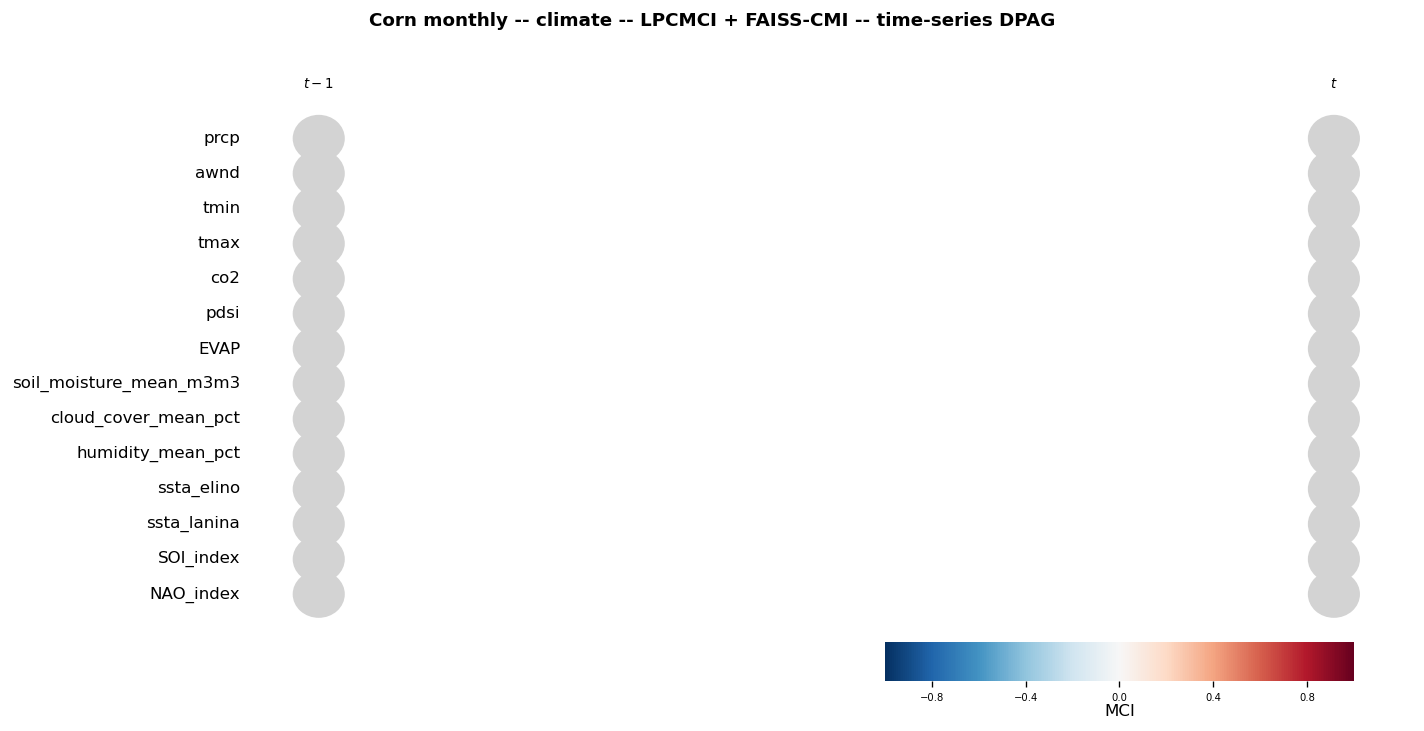


  -- climate_rv (15 vars) --  elapsed: 18.8s
  No edges in the learned DPAG.
  No edges to plot.


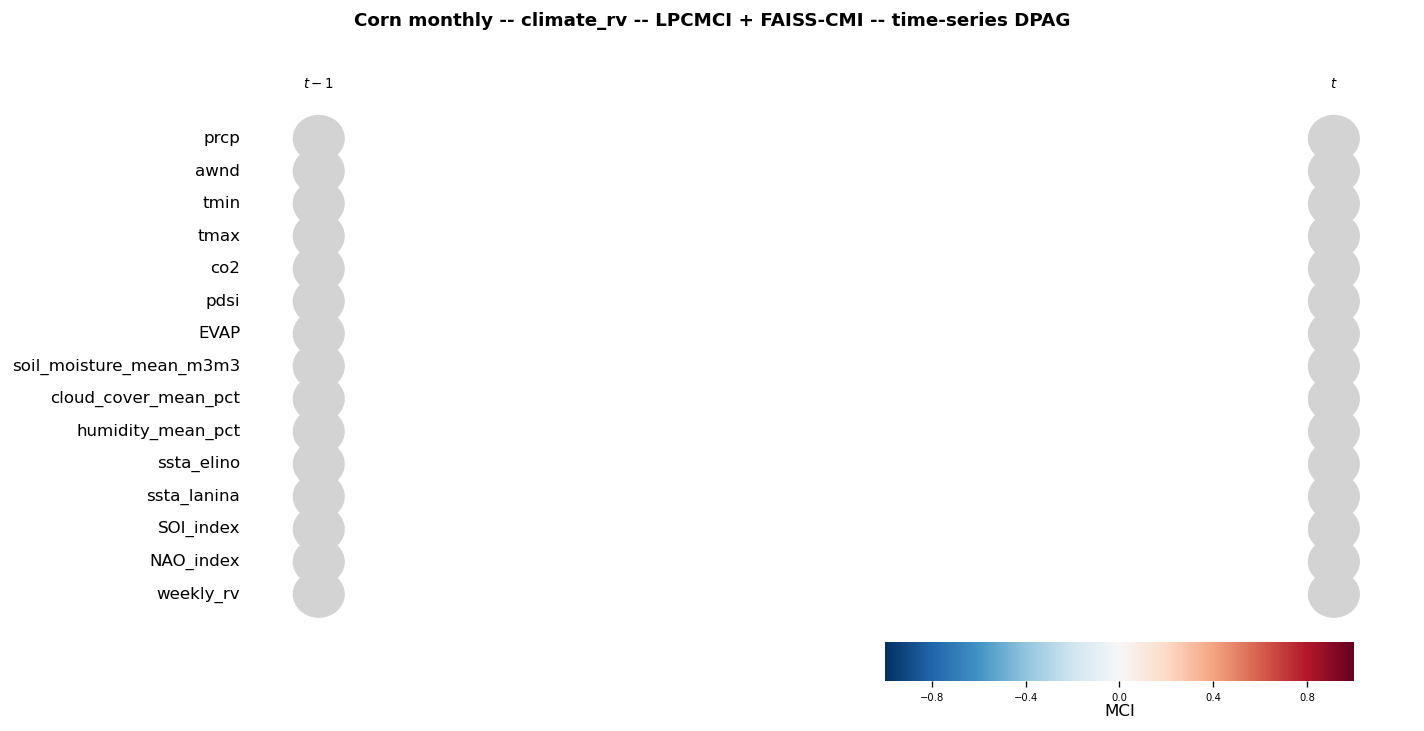


  -- macro_climate_rv (19 vars) --  elapsed: 29.2s
  No edges in the learned DPAG.
  No edges to plot.


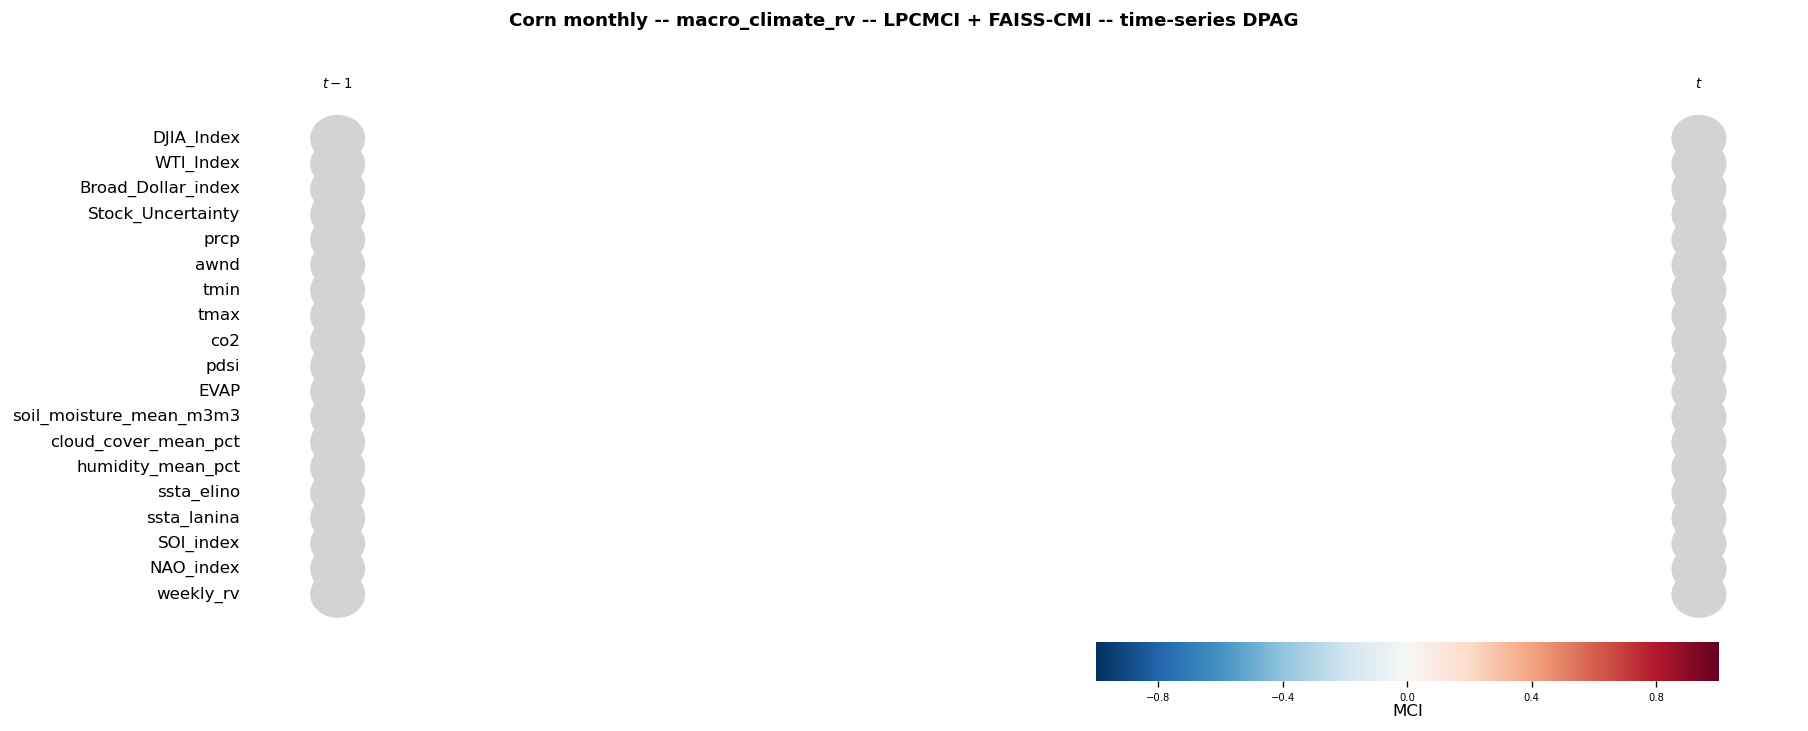


  -- macro_news_climate_rv (22 vars) --  elapsed: 39.9s
  No edges in the learned DPAG.
  No edges to plot.


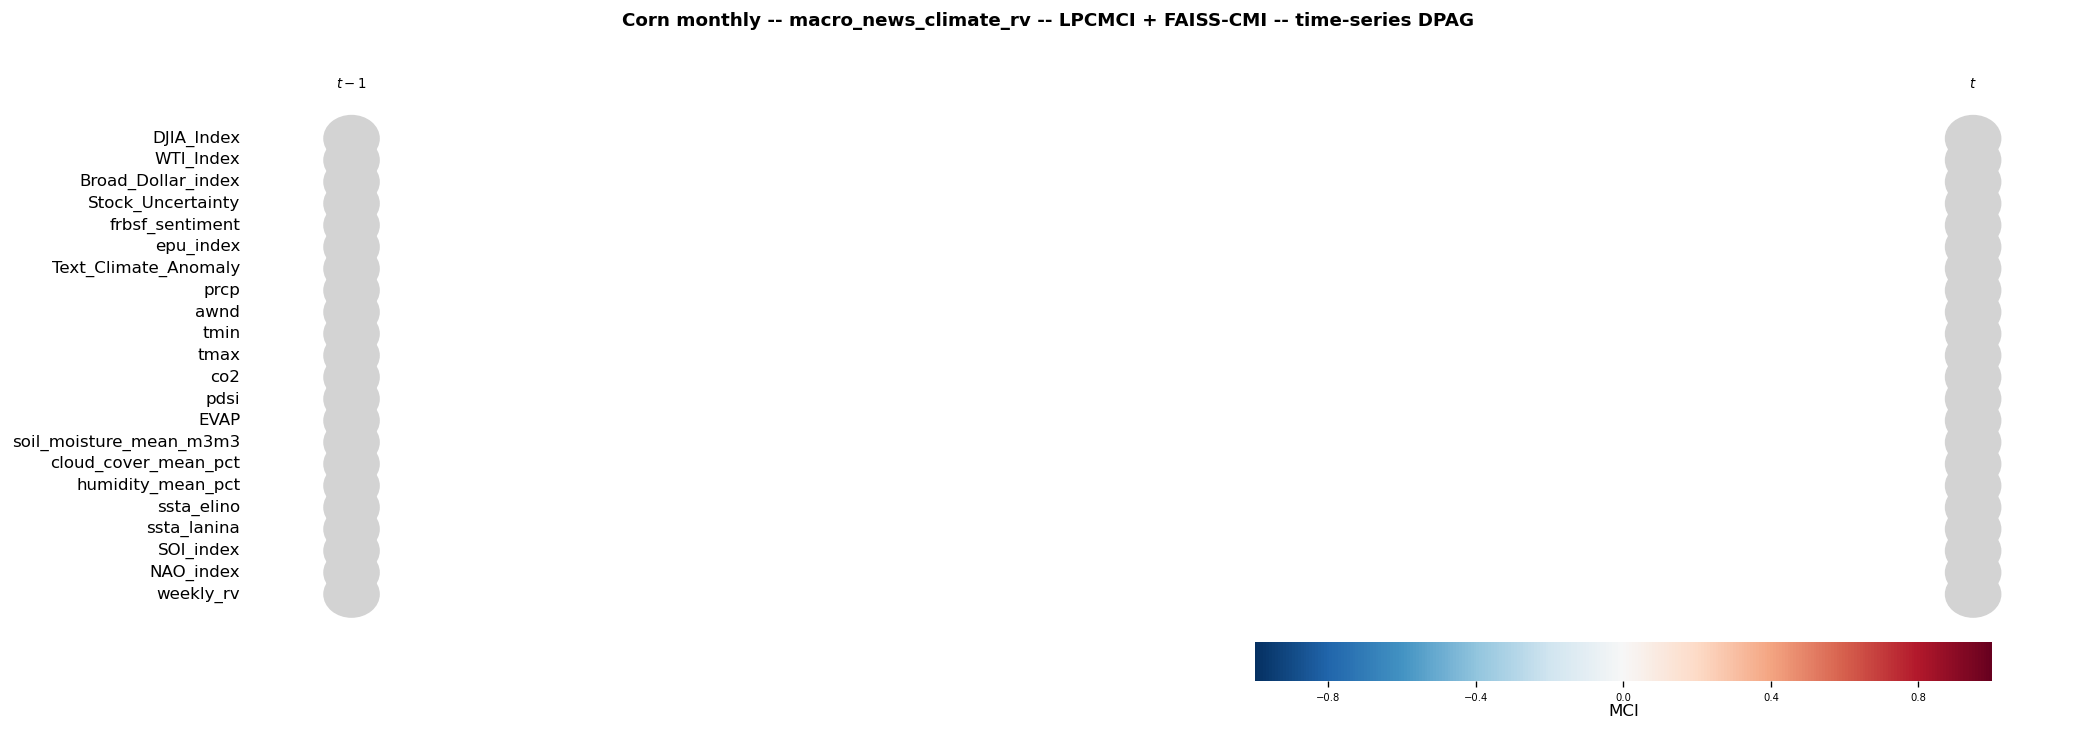


######################################################################
  CROP: SOYBEAN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 -> 2025-03-01)
  -- climate (reusing shared result) --

  -- climate_rv (15 vars) --  elapsed: 18.1s
  No edges in the learned DPAG.
  No edges to plot.


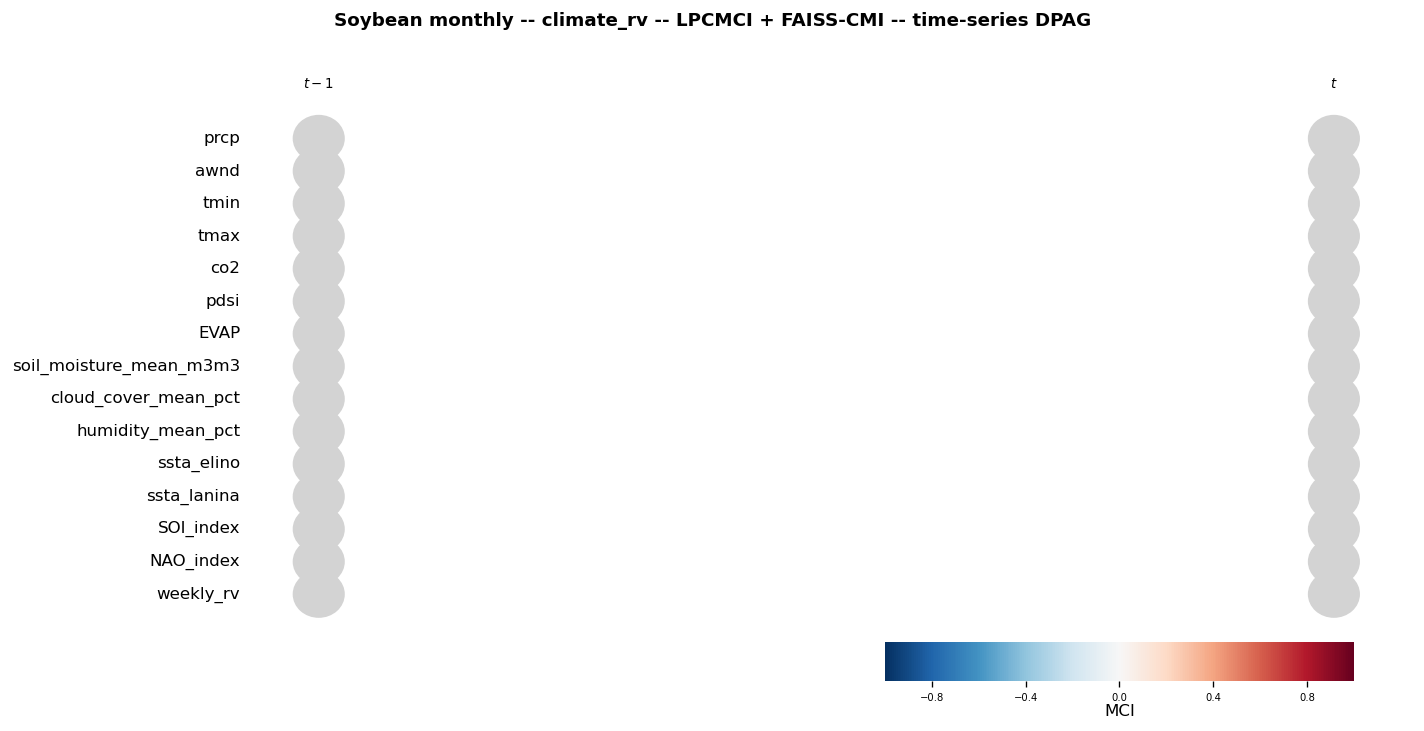


  -- macro_climate_rv (19 vars) --  elapsed: 29.3s
  No edges in the learned DPAG.
  No edges to plot.


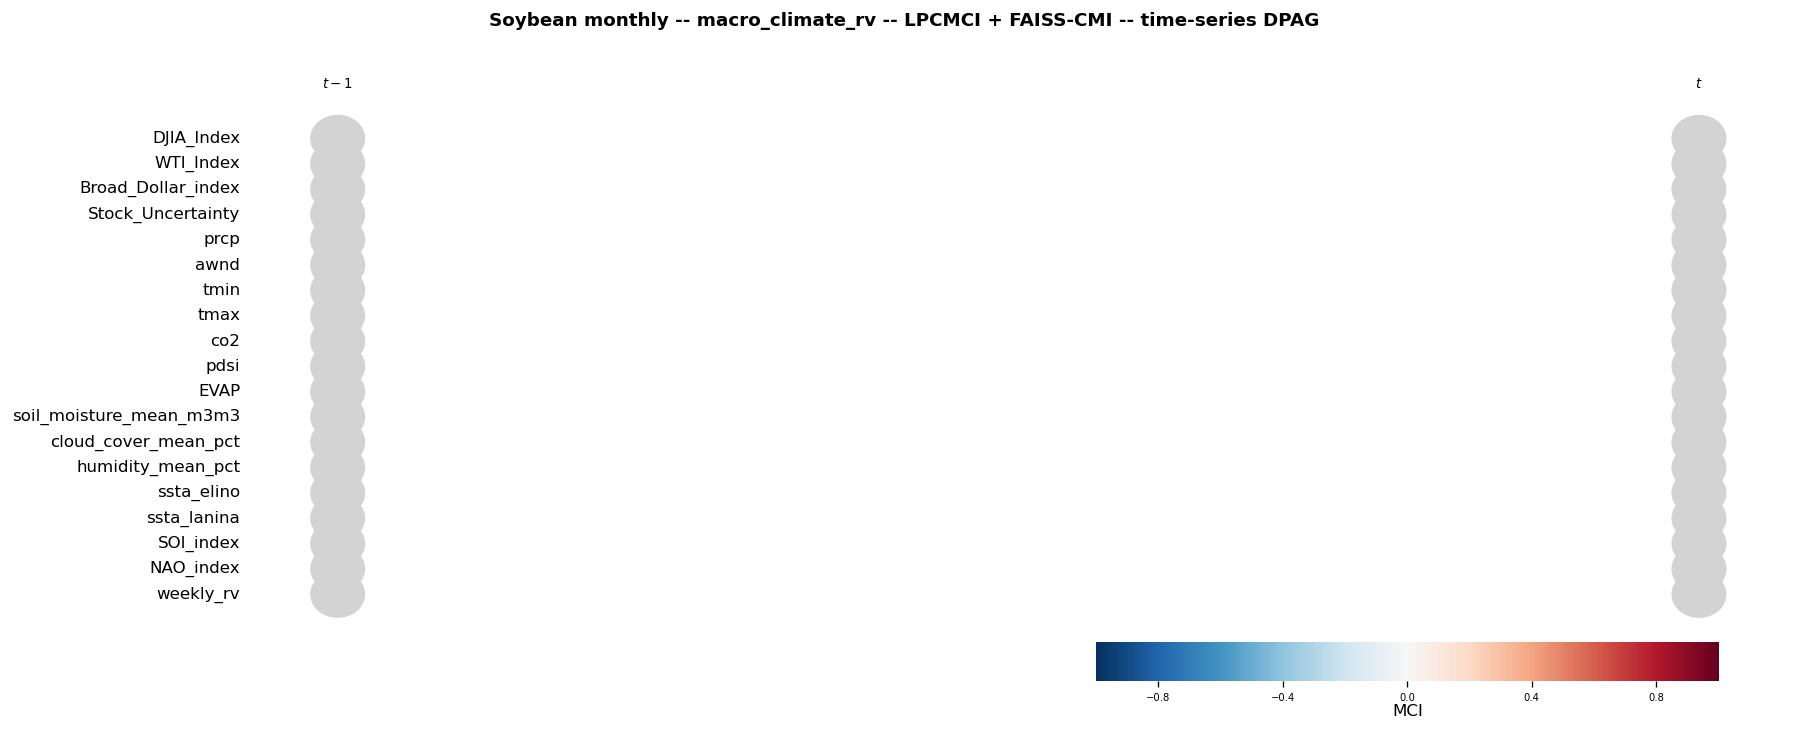


  -- macro_news_climate_rv (22 vars) --  elapsed: 40.7s
  No edges in the learned DPAG.
  No edges to plot.


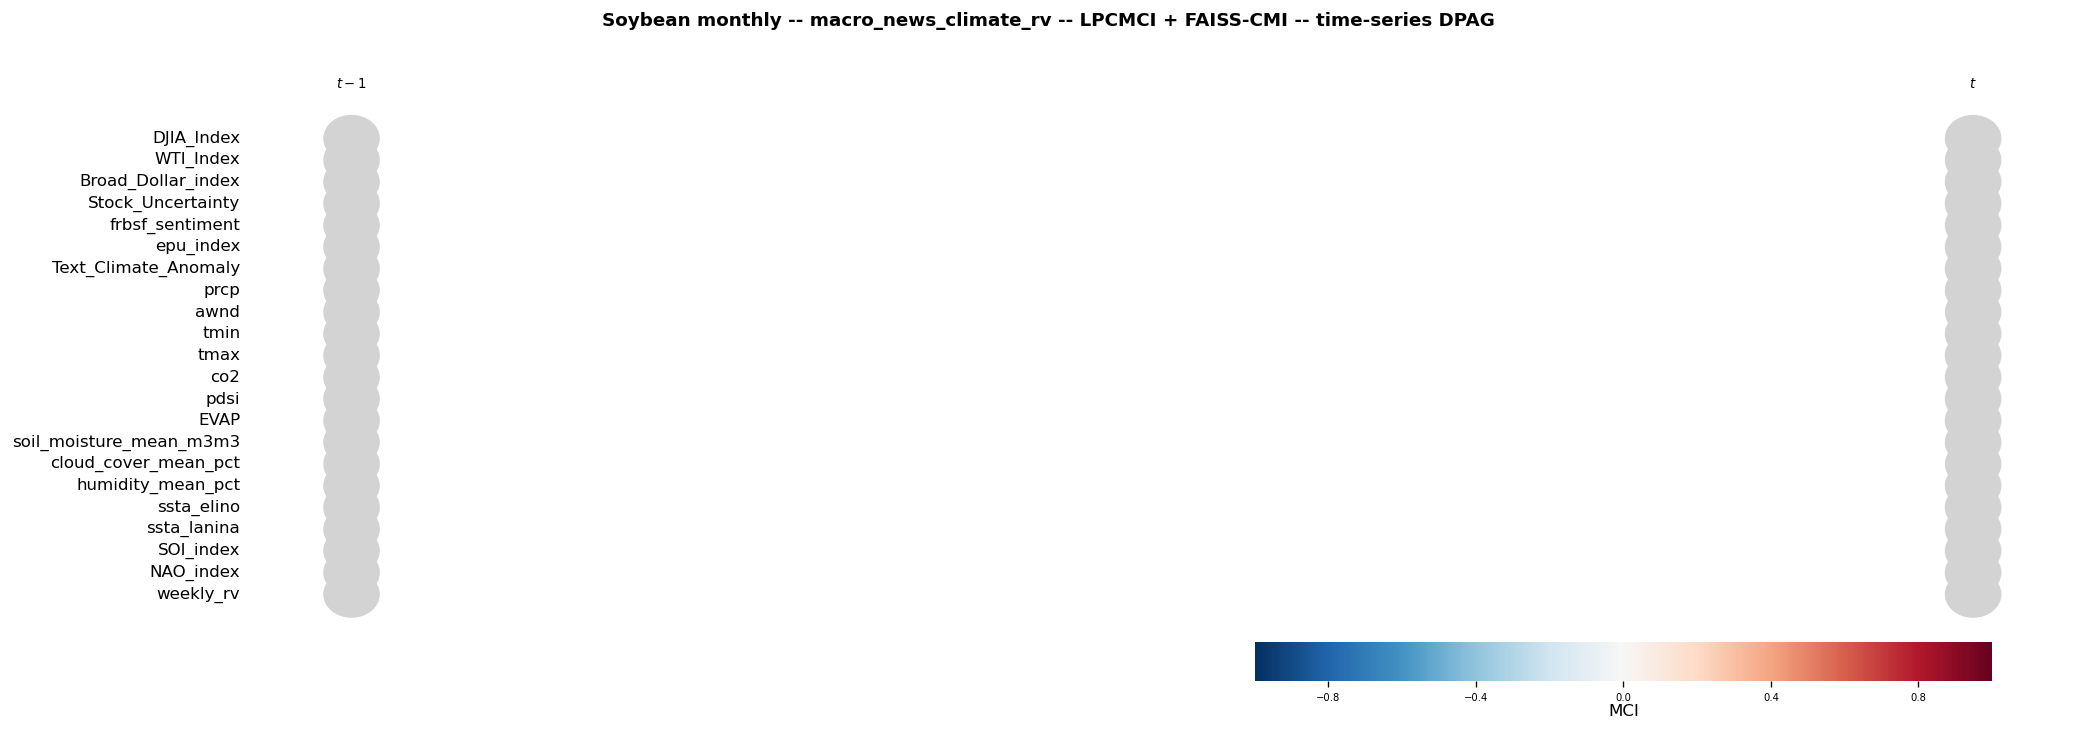


######################################################################
  CROP: WHEAT  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 -> 2025-03-01)
  -- climate (reusing shared result) --

  -- climate_rv (15 vars) --  elapsed: 18.9s
  No edges in the learned DPAG.
  No edges to plot.


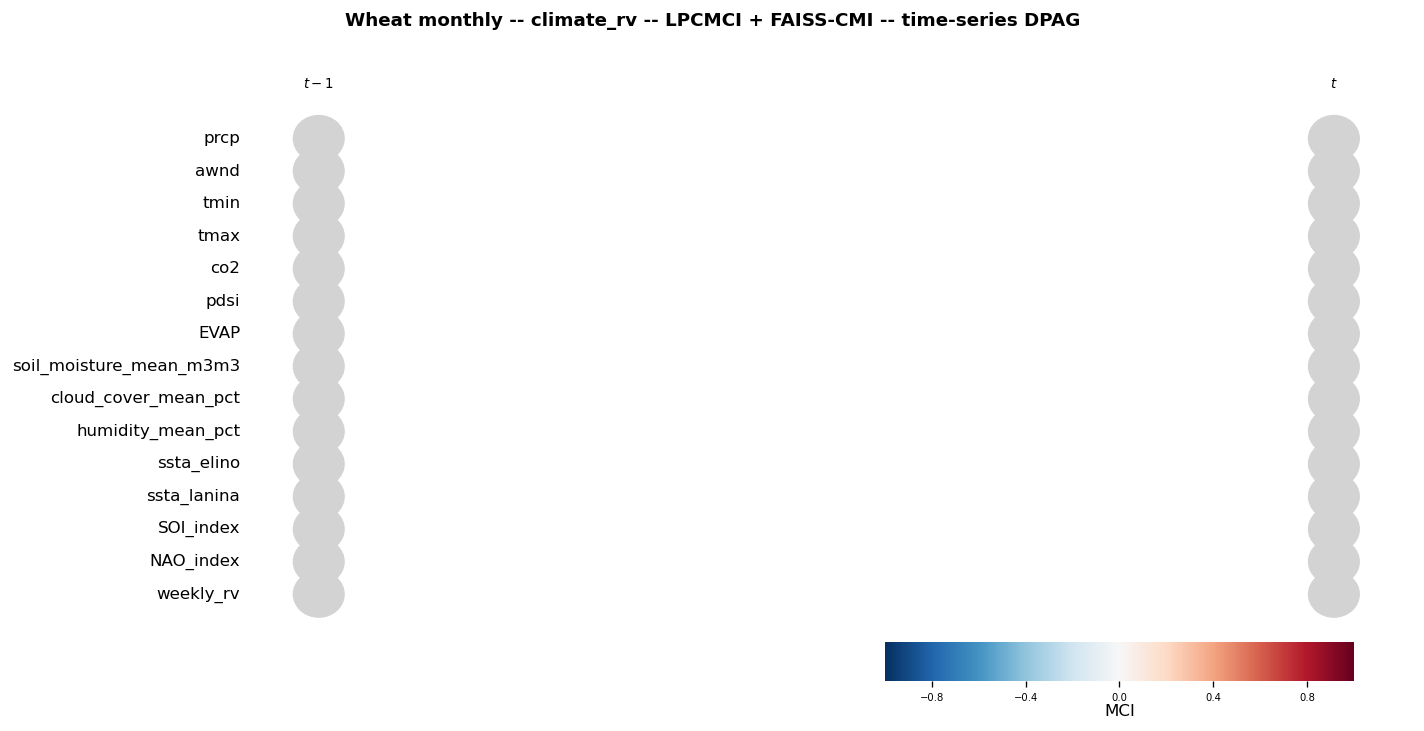


  -- macro_climate_rv (19 vars) --  elapsed: 29.2s
  No edges in the learned DPAG.
  No edges to plot.


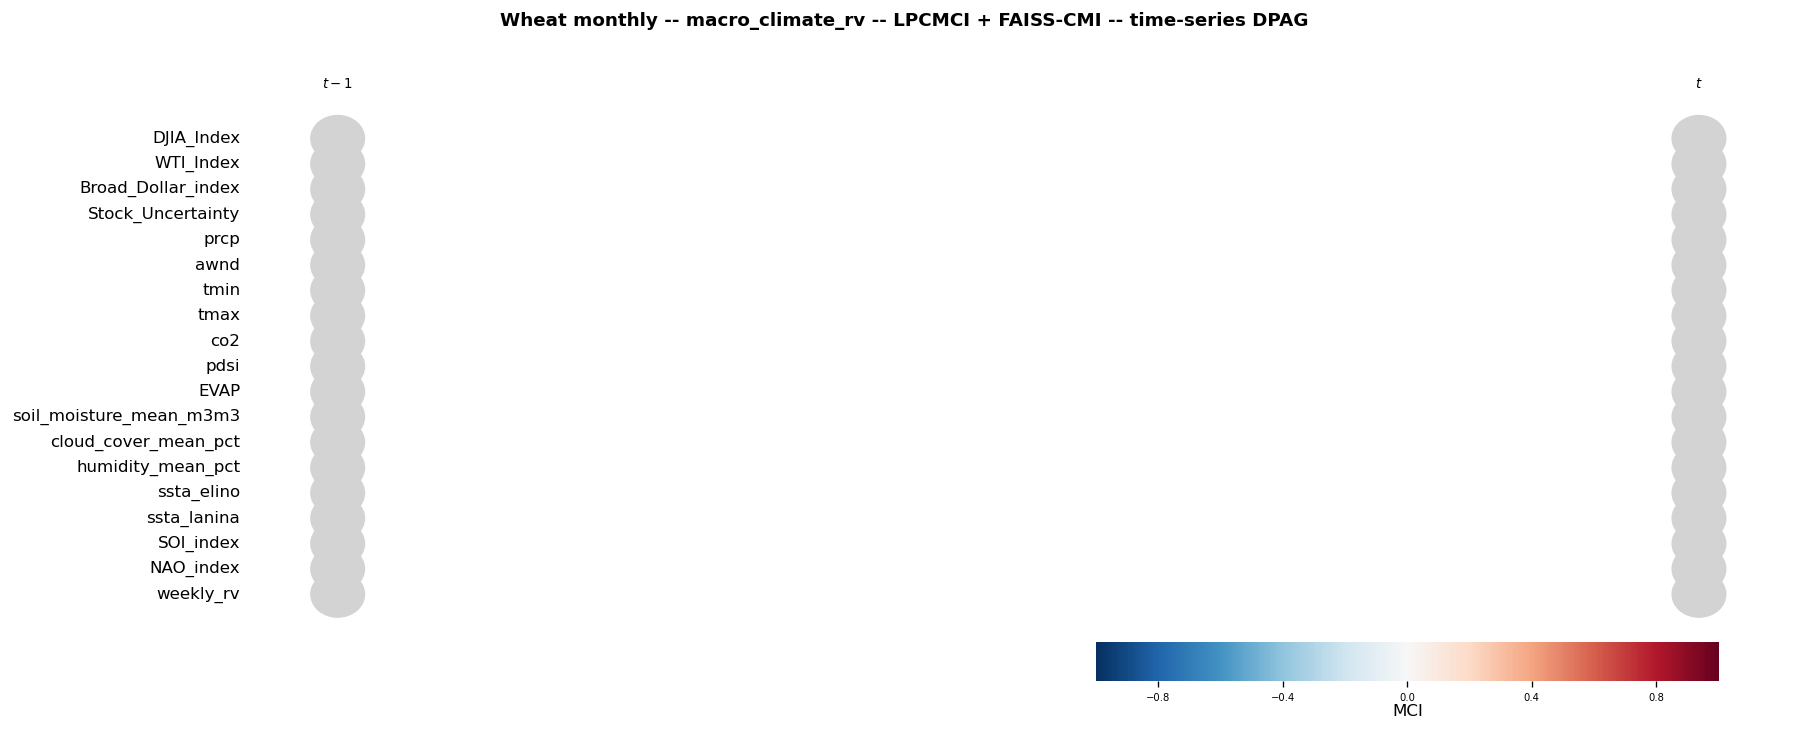


  -- macro_news_climate_rv (22 vars) --  elapsed: 41.2s
  No edges in the learned DPAG.
  No edges to plot.


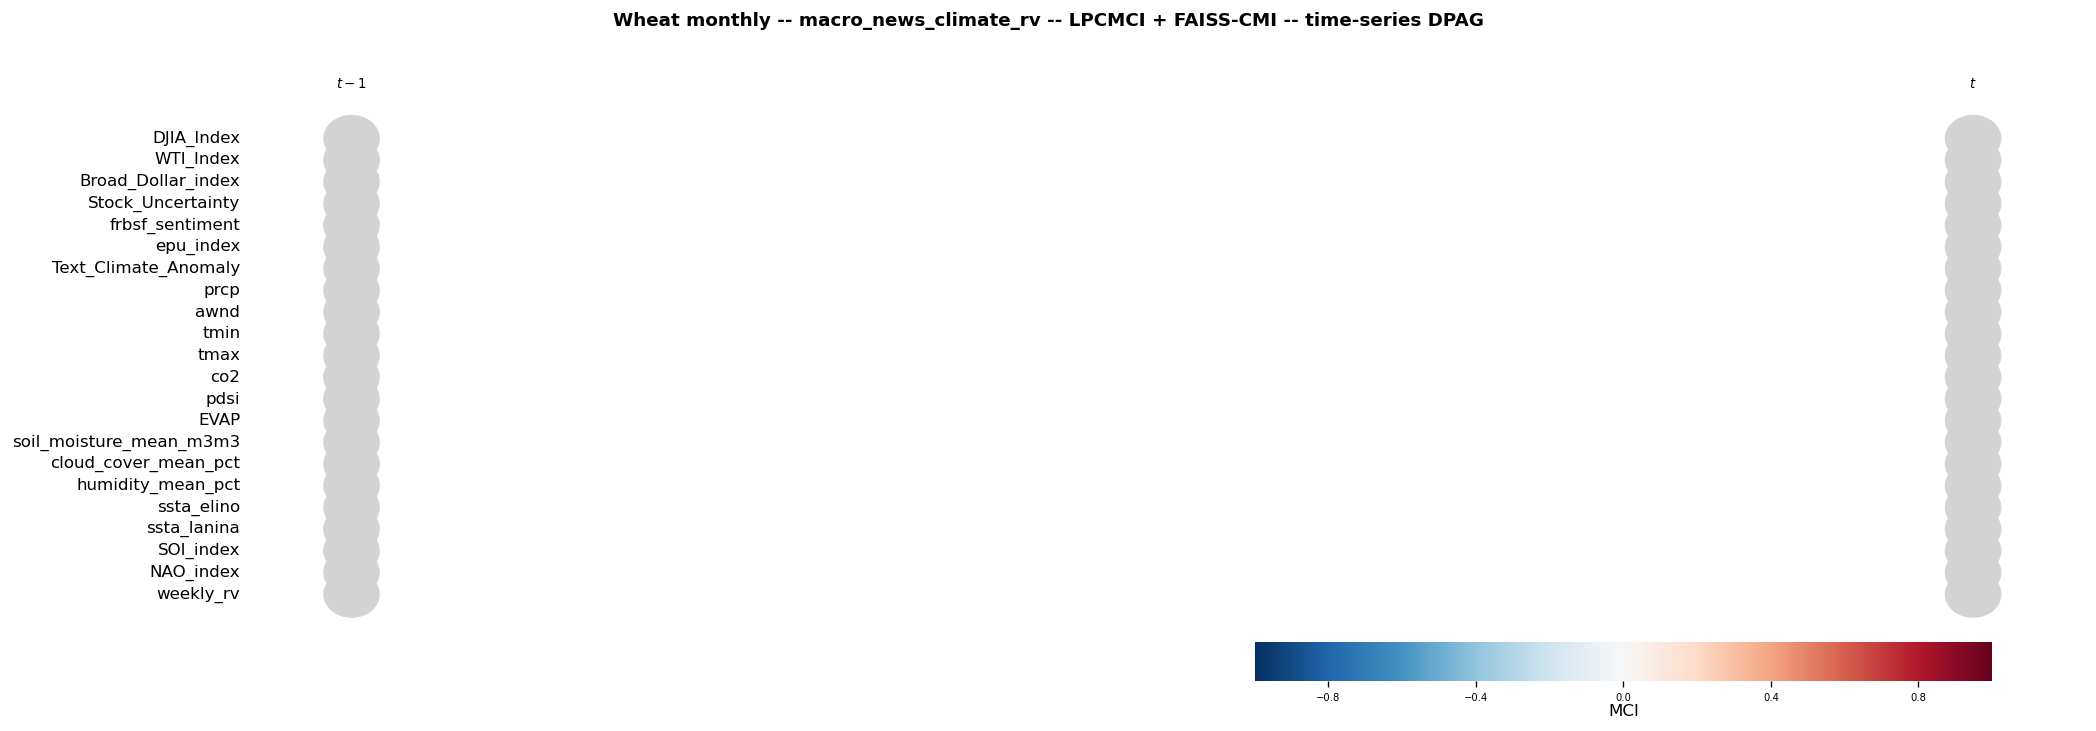


All runs done.


In [12]:
all_results: dict[str, dict] = {}
climate_result: dict | None = None  # climate is crop-agnostic -- run once, reuse

for crop in CROPS:
    sep = '#' * 70
    print(f'\n{sep}')
    print(f'  CROP: {crop.upper()}  |  FREQUENCY: {FREQUENCY.upper()}')
    print(sep)

    arr_normal, all_cols, dates = load_and_preprocess(crop, FREQUENCY)
    print(f'  Preprocessed: {arr_normal.shape}  '
          f'({dates.min().date()} -> {dates.max().date()})')

    all_results[crop] = {}

    for fs_name, groups in FEATURE_SETS.items():
        if fs_name == 'climate' and climate_result is not None:
            all_results[crop][fs_name] = climate_result
            print('  -- climate (reusing shared result) --')
            continue

        col_names = [c for c in build_cols(groups) if c in all_cols]

        t0  = time.time()
        res = run_lpcmci(
            col_names=col_names,
            arr_preprocessed=arr_normal,
            all_cols=all_cols,
            tau_max=TAU_MAX,
        )
        elapsed = time.time() - t0

        if fs_name == 'climate':
            climate_result = res

        all_results[crop][fs_name] = res

        print(f'\n  -- {fs_name} ({len(col_names)} vars) --  elapsed: {elapsed:.1f}s')
        log_links(res)
        plot_results(res, title=f'{crop.capitalize()} {FREQUENCY} -- {fs_name} -- LPCMCI + {METHOD_LABEL}')

print('\nAll runs done.')

## Cross-Crop Comparison: Causal vs Confounded Links into `weekly_rv`

For each RV feature set, every edge touching `weekly_rv` — whether a directed candidate cause or a
`<->` confounded pairing that PCMCI would have missed entirely (it can only report `-->` or `o-o`).

In [13]:
for fs_name in ['climate_rv', 'macro_climate_rv', 'macro_news_climate_rv']:
    print(f'\n{"="*70}')
    print(f'  Feature set: {fs_name}')
    print(f'{"="*70}')
    for crop in CROPS:
        links = extract_rv_links(all_results[crop][fs_name])
        print(f'\n  {crop.upper()}:')
        if links.empty:
            print('    No edges touching weekly_rv.')
        else:
            print(links.sort_values('category').to_string(index=False,
                  float_format='{:.3f}'.format, col_space=16))


  Feature set: climate_rv

  CORN:
    No edges touching weekly_rv.

  SOYBEAN:
    No edges touching weekly_rv.

  WHEAT:
    No edges touching weekly_rv.

  Feature set: macro_climate_rv

  CORN:
    No edges touching weekly_rv.

  SOYBEAN:
    No edges touching weekly_rv.

  WHEAT:
    No edges touching weekly_rv.

  Feature set: macro_news_climate_rv

  CORN:
    No edges touching weekly_rv.

  SOYBEAN:
    No edges touching weekly_rv.

  WHEAT:
    No edges touching weekly_rv.


## LPCMCI vs PCMCI+FAISS-CMI — Does Latent-Confounder-Robust Analysis Change the Story?

Re-runs plain `PCMCI.run_pcmci` + FAISS-CMI (`pcmci_cmi.ipynb`'s settings: `pc_alpha=0.05`, `alpha_level=0.05`, `fdr_bh`, `max_combinations=3`, `sig_samples=200`)
on the `climate_rv` feature set and checks, for every parent PCMCI found for `weekly_rv`, what LPCMCI
concluded about that same pair. A link PCMCI calls significant but LPCMCI marks `<->` is a link that
should **not** be interpreted causally — it is exactly the kind of false positive causal sufficiency
produces.

In [14]:
def run_pcmci_baseline(col_names, arr_preprocessed, all_cols, tau_max,
                        pc_alpha=0.05, alpha_level=0.05, fdr_method='fdr_bh', max_combinations=3):
    indices     = [all_cols.index(c) for c in col_names]
    data_subset = arr_preprocessed[:, indices]
    dataframe = pp.DataFrame(data_subset, var_names=col_names, datatime={0: np.arange(len(data_subset))})
    cmi = FAISSCMI(
        k=CMI_K, use_gpu=FAISS_USE_GPU, gpu_device=0,
        transform='ranks', jitter=1e-6,
        significance='shuffle_test', sig_samples=200, seed=RANDOM_SEED,
    )
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=cmi, verbosity=0)
    results = pcmci.run_pcmci(tau_min=1, tau_max=tau_max, pc_alpha=pc_alpha,
                               alpha_level=alpha_level, fdr_method=fdr_method,
                               max_combinations=max_combinations)
    q_matrix = pcmci.get_corrected_pvalues(p_matrix=results['p_matrix'], tau_max=tau_max, fdr_method=fdr_method)
    graph    = pcmci.get_graph_from_pmatrix(p_matrix=q_matrix, alpha_level=alpha_level, tau_min=1, tau_max=tau_max)
    return {'graph': graph, 'val_matrix': results['val_matrix'], 'q_matrix': q_matrix, 'col_names': col_names}


print(f'{"Crop":<10} {"Cause":<24} {"Lag":<4} {"PCMCI+FAISS-CMI":<16} {"LPCMCI verdict":<32}')
print('-' * 88)

for crop in CROPS:
    arr_normal, all_cols, _ = load_and_preprocess(crop, FREQUENCY)
    col_names = [c for c in build_cols(FEATURE_SETS['climate_rv']) if c in all_cols]
    pc_res = run_pcmci_baseline(col_names, arr_normal, all_cols, tau_max=BASELINE_TAU_MAX)

    rv_idx = col_names.index('weekly_rv')
    pcmci_parents = [
        (col_names[i], tau) for i in range(len(col_names))
        for tau in range(1, BASELINE_TAU_MAX + 1)
        if i != rv_idx and pc_res['graph'][i, rv_idx, tau] not in ('', 'o-o')
    ]

    lp_df = extract_rv_links(all_results[crop]['climate_rv'])
    lp_into_rv    = lp_df[lp_df['effect'] == 'weekly_rv'] if not lp_df.empty else pd.DataFrame()
    lp_confounded = set(
        frozenset((r['cause'], r['effect'])) for _, r in lp_df.iterrows() if r['category'] == 'confounded'
    ) if not lp_df.empty else set()

    if not pcmci_parents:
        print(f'{crop:<10} (no significant PCMCI+FAISS-CMI parents of weekly_rv)')
        continue

    for cause, tau in pcmci_parents:
        if frozenset((cause, 'weekly_rv')) in lp_confounded:
            verdict = 'DOWNGRADED -> confounded (<->)'
        else:
            match = lp_into_rv[(lp_into_rv['cause'] == cause) & (lp_into_rv['lag'] == tau)] if not lp_into_rv.empty else pd.DataFrame()
            verdict = f"confirmed: {match.iloc[0]['category']}" if not match.empty else 'not recovered by LPCMCI'
        print(f'{crop:<10} {cause:<24} {tau:<4} {"significant":<16} {verdict:<32}')

Crop       Cause                    Lag  PCMCI+FAISS-CMI  LPCMCI verdict                  
----------------------------------------------------------------------------------------
corn       (no significant PCMCI+FAISS-CMI parents of weekly_rv)
soybean    (no significant PCMCI+FAISS-CMI parents of weekly_rv)
wheat      (no significant PCMCI+FAISS-CMI parents of weekly_rv)


## Summary

**Preprocessing:** identical to every other notebook in this project.

**LPCMCI + FAISSCMI config:** `tau_max=1`, `pc_alpha=0.01`, `n_preliminary_iterations=0`,
`max_p_global=1`, `max_p_non_ancestral=0`, `max_q_global=1`, `k=0.1` (fractional),
`sig_samples=50` for LPCMCI's own runs (`sig_samples=200` for the Section 9 baseline comparison) —
see Runtime Tuning for the measurements behind these choices.

**Reading the results:** as with `lpcmci_gpdc.ipynb`, the shorter `tau_max` and reduced `sig_samples`
mean this notebook's DPAG is a coarser, faster sketch than `pcmci_cmi.ipynb`'s production run — useful
for the causal-vs-confounded question this notebook targets, not as a replacement for that notebook's
own significant-links analysis.

**Cross-notebook check:** if the same pair is marked `<->` (confounded) in `lpcmci_parcorr.ipynb`,
`lpcmci_gpdc.ipynb`, and here, that is reasonably strong evidence the link is a genuine confounding
artifact rather than a CI-test-specific quirk.